# Step 1: Member C (The Strategic-Behavior Analyst)
Objective: Apply game theory to model the incentives that exacerbate structural and causal risks. We will define governance and behavioral risks, identify a strategic coordination failure (like a cross-border bank run), and model the incentives leading to a bad equilibrium.

=== Herding Behavior: Capital Flight from the US (2008-Q1 to 2009-Q1) ===


,2008-Q1,2009-Q1,Withdrawal ($M),% Drop
Reporting country,,,,
France,245274.0,151760.0,93514.0,38.126340
Germany,591367.0,397619.0,193748.0,32.762734
Switzerland,228099.0,157308.0,70791.0,31.035208
United Kingdom,456233.0,439793.0,16440.0,3.603422
Japan,607015.0,601977.0,5038.0,0.829963


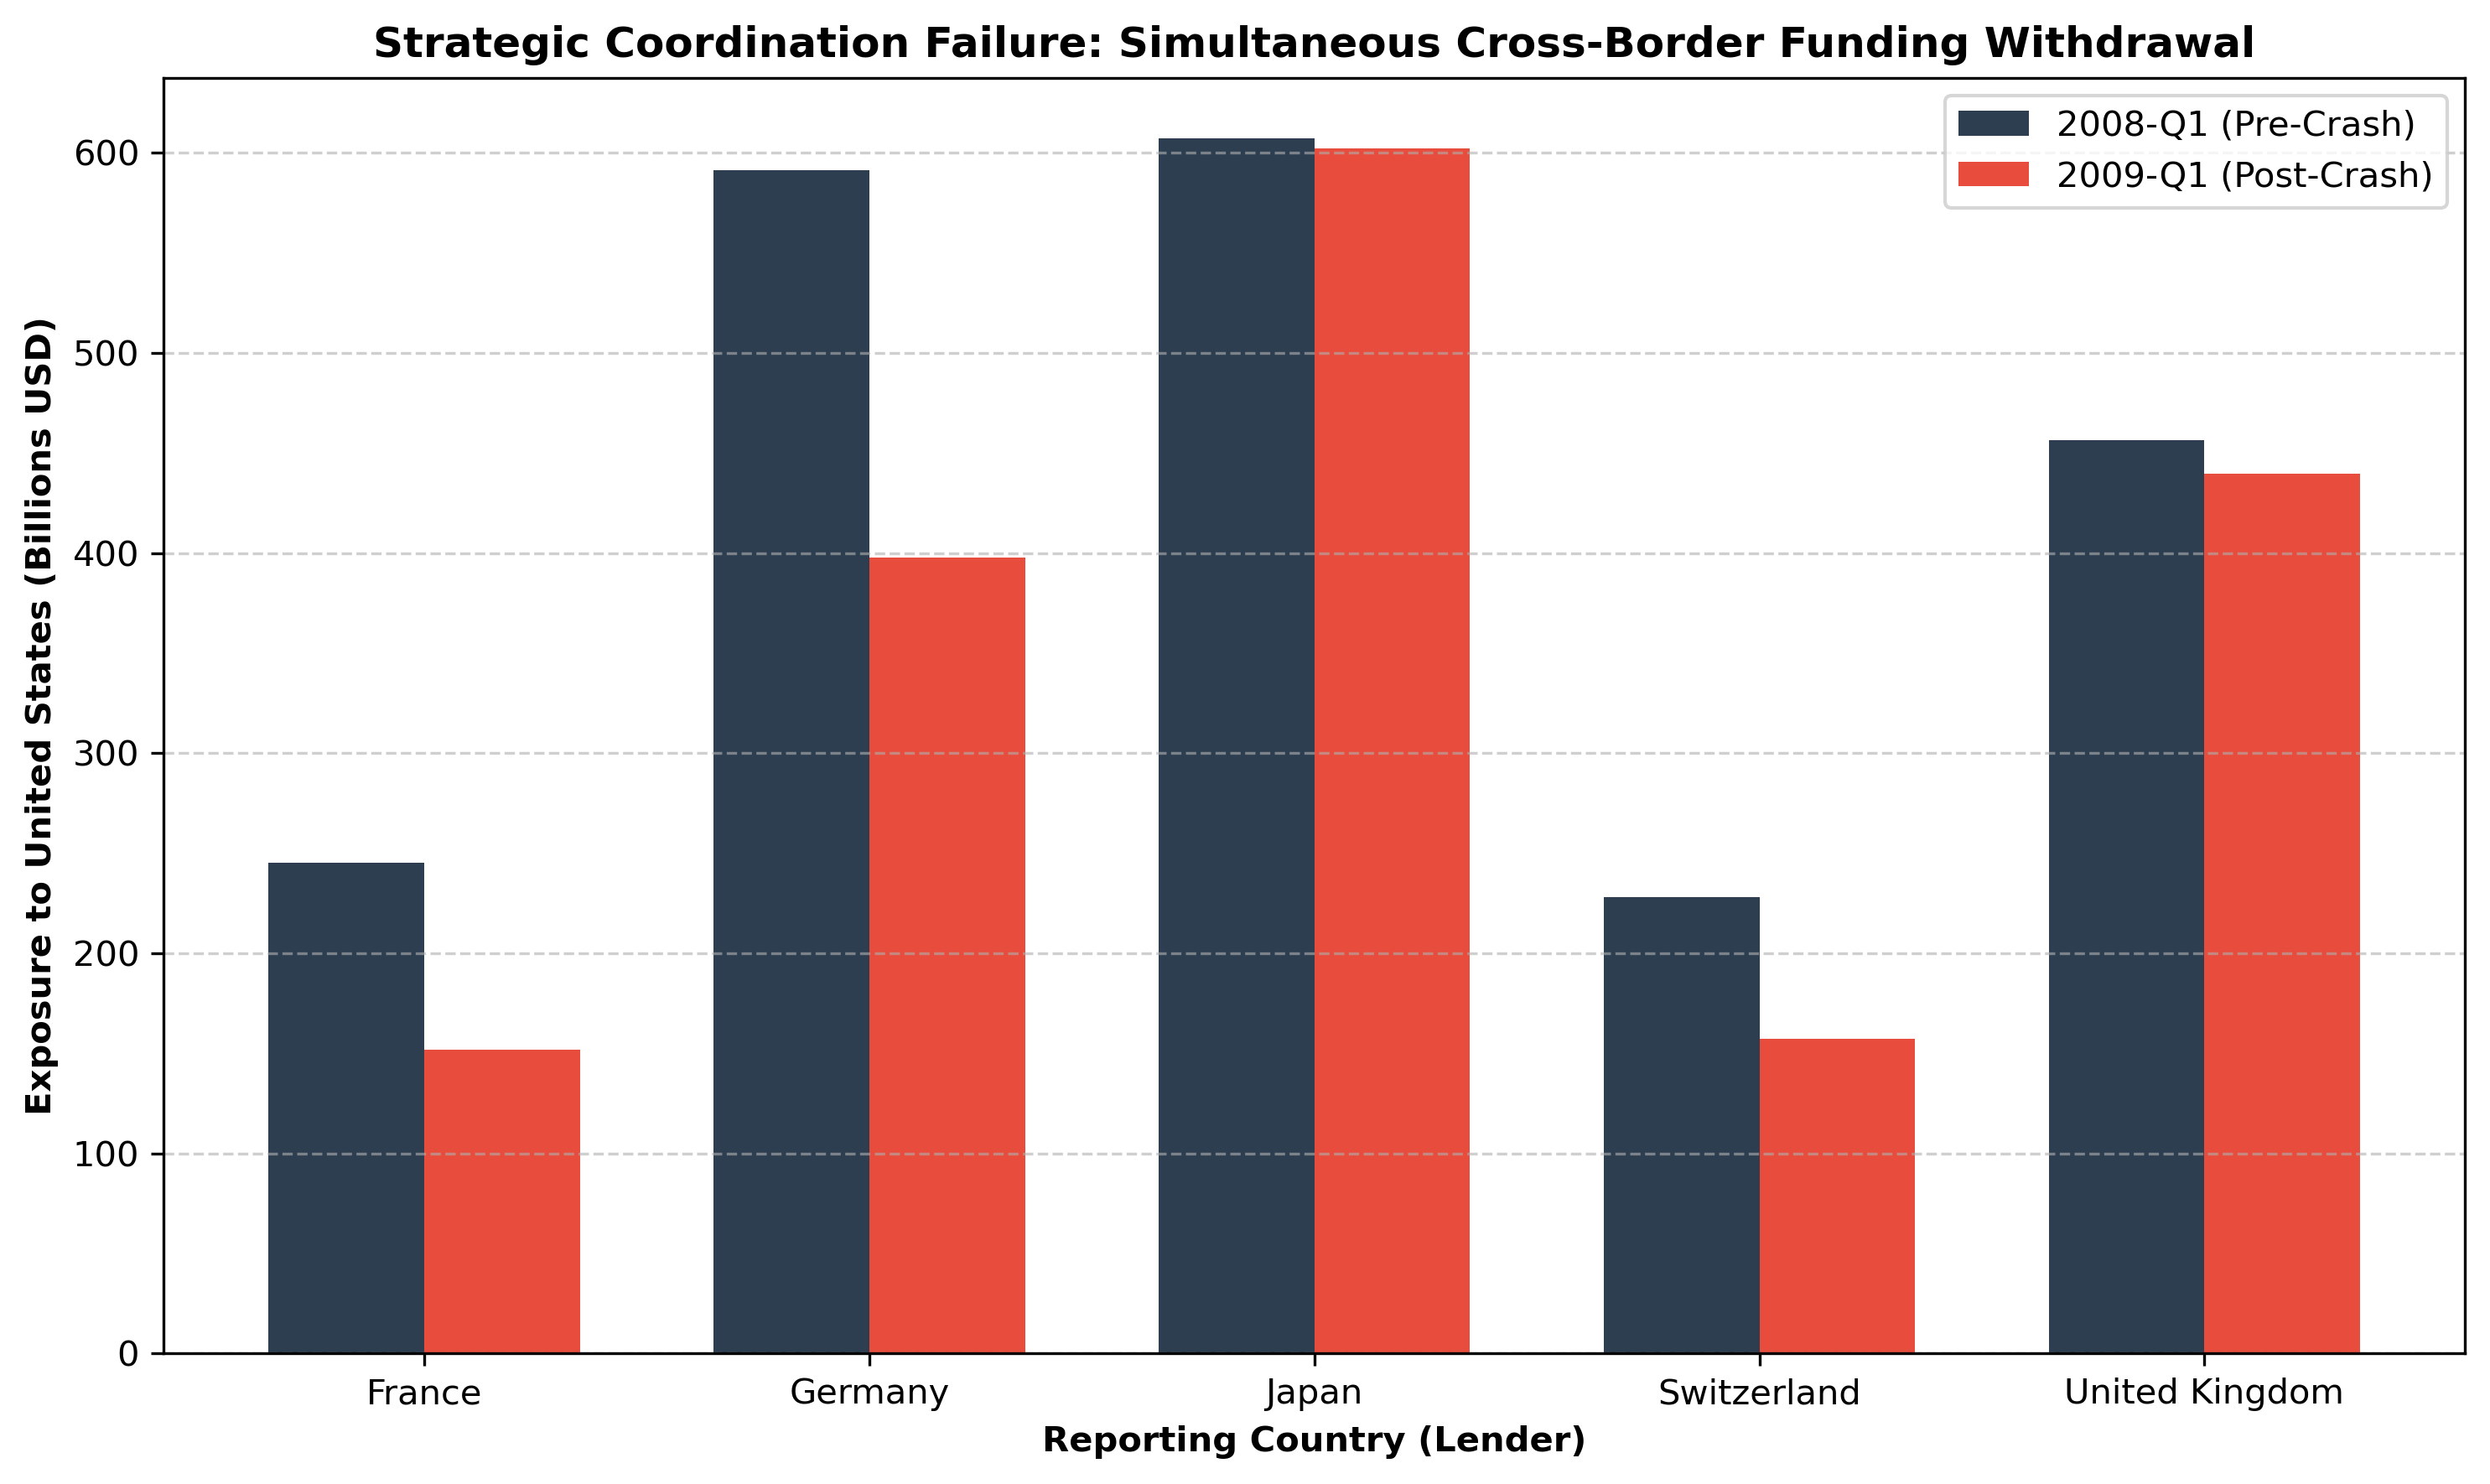

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")

# Load the positive edges dataset (Long format)
df = pd.read_csv(PROCESSED_DIR / "bis_cbs_network_2007_2010_positive_edges.csv")

# -------------------------------------------------------------
# C1 & C2: Strategic Behavior - The Cross-Border Bank Run
# -------------------------------------------------------------

# Filter for claims on the United States
us_borrowing = df[df['Counterparty country'] == 'United States'].copy()

# Select key global lenders to the US identified in previous steps
key_lenders = ['Germany', 'United Kingdom', 'Japan', 'France', 'Switzerland']
us_borrowing_key = us_borrowing[us_borrowing['Reporting country'].isin(key_lenders)]

# Extract their exposures for 2008-Q1 (pre-crash) and 2009-Q1 (post-crash)
df_2008 = us_borrowing_key[us_borrowing_key['period'] == '2008-Q1'][['Reporting country', 'claim_value_usd_millions']]
df_2008 = df_2008.rename(columns={'claim_value_usd_millions': '2008-Q1'})

df_2009 = us_borrowing_key[us_borrowing_key['period'] == '2009-Q1'][['Reporting country', 'claim_value_usd_millions']]
df_2009 = df_2009.rename(columns={'claim_value_usd_millions': '2009-Q1'})

# Merge to compare
flight_to_safety = pd.merge(df_2008, df_2009, on='Reporting country', how='outer').set_index('Reporting country')

# Calculate the absolute withdrawal and percentage drop
flight_to_safety['Withdrawal ($M)'] = flight_to_safety['2008-Q1'] - flight_to_safety['2009-Q1']
flight_to_safety['% Drop'] = (flight_to_safety['Withdrawal ($M)'] / flight_to_safety['2008-Q1']) * 100

print("=== Herding Behavior: Capital Flight from the US (2008-Q1 to 2009-Q1) ===")
display(flight_to_safety.sort_values('% Drop', ascending=False))

# Plot the Bank Run (Prisoner's Dilemma Outcome)
labels = flight_to_safety.index
pre_crash = flight_to_safety['2008-Q1'] / 1000 # Convert to Billions for cleaner axis
post_crash = flight_to_safety['2009-Q1'] / 1000

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6), dpi=300)
plt.bar(x - width/2, pre_crash, width, label='2008-Q1 (Pre-Crash)', color='#2c3e50')
plt.bar(x + width/2, post_crash, width, label='2009-Q1 (Post-Crash)', color='#e74c3c')

plt.ylabel('Exposure to United States (Billions USD)', fontweight='bold')
plt.xlabel('Reporting Country (Lender)', fontweight='bold')
plt.title('Strategic Coordination Failure: Simultaneous Cross-Border Funding Withdrawal', fontweight='bold')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_c1_strategic_withdrawal.png")
plt.show()

## Member C: The Strategic-Behavior Analyst
**Disruptive Force Focus:** Governance/Policy Risk (Module 4) & Behavioral Risk (Module 6)  
**Primary Analytical Lens:** Basic Game Theory  

---

### C1: Behavioral and Governance Risk Foundations

#### 1. Theoretical Definitions and Strategic Patterns
*   **Behavioral Risk:** The systemic danger introduced by bounded rationality, panic, and heuristic decision-making. In networked environments, it manifests as **herding**—where actors abandon private information to mimic the actions of the crowd, often leading to self-fulfilling prophecies like bank runs (Banerjee, 1992).
*   **Governance and Policy Risk:** The vulnerability arising when regulatory frameworks, jurisdictional boundaries, or institutional interventions fail to align private incentives with macro-systemic stability. It often results in regulatory arbitrage or moral hazard.
*   **Strategic Patterns:** 
    *   *Coordination Failure:* When autonomous actors fail to reach a mutually beneficial state due to a lack of trust or communication.
    *   *Prisoner's Dilemma:* A strict coordination failure where the dominant strategy for every individual results in the worst possible collective equilibrium (Nash Equilibrium).

#### 2. Empirical Identification of Interdependent Actions
Reading the dashboard data (Bank for International Settlements [BIS], 2026), we identify a classic scenario where an actor’s best move depends entirely on the actions of others: **cross-border funding withdrawal from a common exposure (The United States).** 

If a European hub suspects the US banking sector is insolvent, its optimal move is to withdraw its USD claims immediately. However, if *every* European hub withdraws simultaneously, they strip the US of vital liquidity, guaranteeing the exact default they are trying to avoid. 

---

### C2: Modeling the 2008 Cross-Border Bank Run

#### 1. The Prisoner's Dilemma: Strategic Withdrawal
We model the 2008 capital flight from the United States as a two-player, non-cooperative game between major European lending hubs (e.g., France and Germany). 

*   **Players:** Hub Bank A (France) and Hub Bank B (Germany).
*   **Strategies:** Roll Over Funding ($R$) or Withdraw/Flee ($W$).
*   **Incentives (Payoffs):** 
    *   If both Roll Over ($R, R$), the US maintains liquidity, and both banks suffer mild impairment but survive (Macro-Optimal).
    *   If Bank A Withdraws while Bank B Rolls Over ($W, R$), Bank A escapes with its capital intact, while Bank B absorbs the entirety of the US default losses. 
    *   If both Withdraw ($W, W$), the US defaults immediately due to a liquidity freeze, heavily impairing both banks and triggering a global recession.

Because $W$ strictly dominates $R$ for both players (withdrawing is always safer regardless of what the other player does), the system naturally gravitates to the bad Nash Equilibrium ($W, W$). 

#### 2. Empirical Evidence of the Bad Equilibrium (Herding)
The BIS (2026) data confirms this exact coordination failure occurred between 2008-Q1 and 2009-Q1:
*   **France** panicked and withdrew $93,514 million (a 38.13% drop in exposure).
*   **Germany** engaged in the same dominant strategy, withdrawing $193,748 million (a 32.76% drop).
*   **Switzerland** followed suit, withdrawing $70,791 million (a 31.04% drop).

This simultaneous capital flight of over $358 billion from just three European hubs stripped the US of short-term liquidity, transforming a localized subprime mortgage shock into a self-fulfilling global systemic collapse.

#### 3. Governance Interventions and the Gaming of Policy
*   **The Intervention:** To halt this Prisoner's Dilemma, global governance institutions (like the US Federal Reserve and the ECB) had to intervene by establishing **Central Bank Liquidity Swap Lines**. By acting as the global lender of last resort, the Fed essentially guaranteed the USD funding needs of foreign hubs, artificially altering the game's payoff matrix to make "Rolling Over" safe again (Obstfeld et al., 2009).
*   **Gaming the Intervention (Moral Hazard):** Rational banking hubs will "game" this intervention in the future. Knowing that central banks will establish unlimited swap lines to prevent a network collapse, global banks are incentivized to take on even larger, more reckless common exposures, engaging in systemic moral hazard because the downside tail-risk has been implicitly nationalized (Farhi & Tirole, 2012).

---

### References
*   Banerjee, A. V. (1992). A simple model of herd behavior. *The Quarterly Journal of Economics*, 100(3), 797–817. https://doi.org/10.2307/2118364
*   Bank for International Settlements. (2026). *Consolidated banking statistics: Detailed view of positions on individual countries (Table B4)* [Data set]. BIS Data Portal. https://data.bis.org/topics/CBS/data
*   Farhi, E., & Tirole, J. (2012). Collective moral hazard, maturity mismatch, and systemic bailouts. *The American Economic Review*, 102(1), 60–93. https://doi.org/10.1257/aer.102.1.60
*   Obstfeld, M., Shambaugh, J. C., & Taylor, A. M. (2009). Financial instability, reserves, and central bank swap lines in the panic of 2008. *The American Economic Review*, 99(2), 480–486. https://doi.org/10.1257/aer.99.2.480